In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Metadaten laden (für das Target y)
df_meta = pd.read_csv("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview_reduced.csv")
print(df_meta.shape)
y = df_meta["is_metal"].values  # Dein Target-Vektor

# Hocheffiziente SOAP-Features laden (für das X)
X = np.load("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_soap_features_reduced.npy")  # Deine Feature-Matrix
print(X.shape)
print('Number of entries: ',df_meta.shape[0])
df_meta.head()


(8000, 10)
(8000, 48870)
Number of entries:  8000


,entry_id,name,formula,spacegroup,crystal_structure,band_gap,is_metal,energy_above_hull,is_stable,delta_e
0,647362,CaInBr3,Br6Ca2In2,Cmcm,orthorhombic,3.243,False,0.000151,False,-1.707352
1,1377987,CaTlBr3,Br6Ca2Tl2,Cmcm,orthorhombic,3.857,False,0.000000,True,-1.794562
2,14334,CdInBr3,Br12Cd4In4,Pnma,orthorhombic,2.176,False,0.007316,False,-0.990649
3,647360,CrInBr3,Br12Cr4In4,P21/c,monoclinic,0.431,False,0.040698,False,-0.846143
4,1368552,CsAgBr3,Ag2Br6Cs2,I4/mmm,tetragonal,0.000,True,0.000000,True,-1.126859


In [3]:
from sklearn.model_selection import train_test_split

# Angenommen, deine Metadaten liegen in einem Pandas DataFrame oder NumPy Array namens `meta`
# Wichtig: meta.shape[0] muss genau so groß sein wie X.shape[0]

# Du übergibst meta einfach als zusätzliches Argument:
X_train, X_test, y_train, y_test, cs_train, cs_test, bg_train, bg_test, he_train, he_test = train_test_split(
    X, 
    y, 
    df_meta['crystal_structure'], 
    df_meta['band_gap'],
    df_meta['energy_above_hull'],
    test_size=0.2, random_state=42
)

print("X_train Form:", X_train.shape)
print("meta_train Form:", bg_train.shape) # Die Zuordnung bleibt perfekt erhalten!

X_train Form: (6400, 48870)
meta_train Form: (6400,)


In [11]:
import time
import joblib
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# XGBoost 3.x: 'use_label_encoder' was removed, and boolean labels are rejected,
# so cast the True/False 'is_metal' target to 0/1.
y_train_enc = y_train.astype(int)
y_test_enc = y_test.astype(int)

# 1. Basis-Klassifikator
#    tree_method="hist" ist der schnelle Histogramm-Algorithmus (wichtig bei 48k Features);
#    n_jobs=-1 nutzt in jedem Fit alle CPU-Kerne.
xgb_model = XGBClassifier(
    tree_method="hist",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
)

# 2. REDUZIERTES Hyperparameter-Grid (fuer den Start klein halten -> kurze Trainingszeit).
#    Nur die wirkungsvollsten Stellschrauben werden variiert; spaeter erweitern.
param_grid_xgb = {
    "n_estimators": [300],
    "max_depth": [6],
    "learning_rate": [0.3],
    "subsample": [0.8],
    "colsample_bytree": [0.5],   # nur 40% der 48k Features pro Baum -> grosser Speed-up
}

# 3. GridSearch.
#    n_jobs=1 hier bewusst: jeder XGBoost-Fit ist bereits multi-core, und X_train ist
#    ~2.5 GB gross -> parallele Folds wuerden es mehrfach kopieren (Speicher-Risiko).
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=3,
    scoring="balanced_accuracy",
    n_jobs=1,
    verbose=2,
)

# 4. Training
print("Starte das (reduzierte) XGBoost Hyperparametertuning...")
t0 = time.time()
grid_search_xgb.fit(X_train, y_train_enc)
print(f"Fertig in {time.time() - t0:.1f} s")

# 5. Bestes Modell
best_xgb_model = grid_search_xgb.best_estimator_
print(f"Beste Parameter: {grid_search_xgb.best_params_}")
print(f"Beste CV-Accuracy: {grid_search_xgb.best_score_:.4f}")

# 6. Speichern
xgb_model_filename = "best_XGB_classifyer_SOAP_bandgap.joblib"
joblib.dump(best_xgb_model, xgb_model_filename)
print(f"XGBoost-Modell gespeichert unter: {xgb_model_filename}")

Starte das (reduzierte) XGBoost Hyperparametertuning...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END colsample_bytree=0.5, learning_rate=0.3, max_depth=6, n_estimators=300, subsample=0.8; total time=  19.2s
[CV] END colsample_bytree=0.5, learning_rate=0.3, max_depth=6, n_estimators=300, subsample=0.8; total time=  20.0s
[CV] END colsample_bytree=0.5, learning_rate=0.3, max_depth=6, n_estimators=300, subsample=0.8; total time=  20.4s
Fertig in 89.5 s
Beste Parameter: {'colsample_bytree': 0.5, 'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Beste CV-Accuracy: 0.8282
XGBoost-Modell gespeichert unter: best_XGB_classifyer_SOAP_bandgap.joblib


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Auswertung auf dem Test-Set
y_pred = best_xgb_model.predict(X_test)

print(f"Test-Accuracy: {accuracy_score(y_test_enc, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(
    y_test_enc, y_pred, target_names=["Kein Metall (False)", "Metall (True)"]
))
print("Confusion Matrix (Zeilen=wahr, Spalten=Vorhersage):")
print(confusion_matrix(y_test_enc, y_pred))

Test-Accuracy: 0.8781

Classification Report:
                     precision    recall  f1-score   support

Kein Metall (False)       0.82      0.77      0.79       488
      Metall (True)       0.90      0.93      0.91      1112

           accuracy                           0.88      1600
          macro avg       0.86      0.85      0.85      1600
       weighted avg       0.88      0.88      0.88      1600

Confusion Matrix (Zeilen=wahr, Spalten=Vorhersage):
[[ 376  112]
 [  83 1029]]


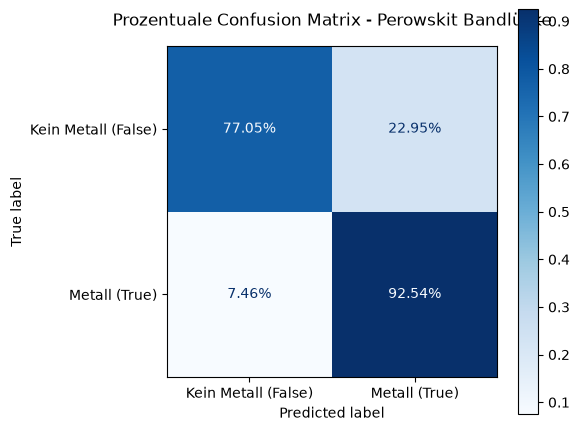

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Konfusionsmatrix PROZENTUAL berechnen (normalize='true' bezieht sich auf die Zeilen)
# Das zeigt, wie viel Prozent der jeweiligen echten Klasse richtig/falsch vorhergesagt wurden.
cm_percentage = confusion_matrix(y_test_enc, y_pred, normalize='true')

# 2. Definiere die Klassennamen
target_names = ["Kein Metall (False)", "Metall (True)"]

# 3. Plot erstellen
fig, ax = plt.subplots(figsize=(6, 5))

# Display-Objekt mit Prozent-Formatierung (.2% zeigt z.B. 85.34%)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2%')

# Titel und Layout
plt.title("Prozentuale Confusion Matrix - Perowskit Bandlücke", fontsize=12, pad=15)
plt.tight_layout()

# 4. Anzeigen oder Speichern
plt.show()
# plt.savefig("confusion_matrix_percentage.png", dpi=300)